# Crop Disease Detection Using Machine Learning

## Problem Statement

The objective of this project is to develop a multi-class
classification model that predicts crop disease status using
environmental, soil, crop and farm-management variables.

Target variable: disease_label

Classes:
- Healthy
- Fungal
- Bacterial
- Pest Damage

Load the dataset. Report shape, data types, and missing values per column


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("crop_disease_dataset.csv")
df.head()

,crop_type,region,season,soil_type,irrigation_method,temperature_C,humidity_percent,rainfall_mm,leaf_wetness_hrs,soil_pH,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,days_since_last_rain,plant_age_days,pesticide_applied,fertilizer_kg_ha,disease_label
0,maize,NaN,Kharif,Clay,FLOOD,26.209077,NaN,101.582271,14.009117,7.085974,39.893186,58.936746,44.894035,NaN,22.0,0.0,53.719785,Fungal
1,Cotton,Central,Rabi,NaN,Sprinkler,33.430687,58.979548,30.296413,11.067606,6.190607,179.824571,88.881893,71.394673,8.0,13.0,0.0,92.819906,Pest Damage
2,cotton,NaN,NaN,CLAY,Drip,28.047989,62.103653,90.564280,21.470657,6.224184,89.690594,17.839237,55.877176,5.0,31.0,0.0,68.282729,Bacterial
3,Soybean,North,Rabi,NaN,NaN,31.411229,54.430551,16.922677,19.309367,6.925993,143.060345,62.503022,91.410148,49.0,116.0,0.0,62.743722,Bacterial
4,cotton,NaN,kharif,sandy,FLOOD,22.822997,56.975619,NaN,12.402934,NaN,134.998574,80.448392,57.815445,29.0,84.0,0.0,84.100232,Healthy


In [3]:
print(df.shape)
print()
print(df.columns)
print()
print(df.info())
print()
print(df.isnull().sum())
print()
print(df.describe())
print()
print(df.describe(include="object"))

(5000, 18)

Index(['crop_type', 'region', 'season', 'soil_type', 'irrigation_method',
       'temperature_C', 'humidity_percent', 'rainfall_mm', 'leaf_wetness_hrs',
       'soil_pH', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha',
       'days_since_last_rain', 'plant_age_days', 'pesticide_applied',
       'fertilizer_kg_ha', 'disease_label'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   crop_type             5000 non-null   object 
 1   region                3943 non-null   object 
 2   season                3595 non-null   object 
 3   soil_type             3875 non-null   object 
 4   irrigation_method     3785 non-null   object 
 5   temperature_C         4750 non-null   float64
 6   humidity_percent      4800 non-null   float64
 7   rainfall_mm           4750 non-null   float64
 8   

In [4]:
data_quality = pd.DataFrame({
    "Data_Type":df.dtypes,
    "Missing_Count":df.isnull().sum(),
    "Missing_Percent":df.isnull().mean()*100,
    "Unique_values":df.nunique()
})
data_quality

,Data_Type,Missing_Count,Missing_Percent,Unique_values
crop_type,object,0,0.00,9
region,object,1057,21.14,7
season,object,1405,28.10,5
soil_type,object,1125,22.50,7
irrigation_method,object,1215,24.30,6
temperature_C,float64,250,5.00,4723
humidity_percent,float64,200,4.00,4783
rainfall_mm,float64,250,5.00,4727
leaf_wetness_hrs,float64,150,3.00,4850
soil_pH,float64,198,3.96,4790


Check all categorical columns for inconsistent capitalisation (e.g. 'WHEAT' vs 'wheat'). List all
unique values found.

In [5]:
categorical_cols = [
    'crop_type',
    'region',
    'season',
    'soil_type',
    'irrigation_method'
]
categorical_cols

['crop_type', 'region', 'season', 'soil_type', 'irrigation_method']

In [6]:
numerical_cols = [
    'temperature_C',
    'humidity_percent',
    'rainfall_mm',
    'leaf_wetness_hrs',
    'soil_pH',
    'nitrogen_kg_ha',
    'phosphorus_kg_ha',
    'potassium_kg_ha',
    'days_since_last_rain',
    'plant_age_days',
    'fertilizer_kg_ha'
]
numerical_cols

['temperature_C',
 'humidity_percent',
 'rainfall_mm',
 'leaf_wetness_hrs',
 'soil_pH',
 'nitrogen_kg_ha',
 'phosphorus_kg_ha',
 'potassium_kg_ha',
 'days_since_last_rain',
 'plant_age_days',
 'fertilizer_kg_ha']

In [7]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


crop_type
['maize' 'Cotton' 'cotton' 'Soybean' 'Rice' 'Wheat' 'WHEAT' 'Maize' 'rice']

region
[nan 'Central' 'North' 'SOUTH' 'East' 'north' 'South' 'West']

season
['Kharif' 'Rabi' nan 'kharif' 'RABI' 'Zaid']

soil_type
['Clay' nan 'CLAY' 'sandy' 'Sandy' 'Loamy' 'loamy' 'Silty']

irrigation_method
['FLOOD' 'Sprinkler' 'Drip' nan 'drip' 'Rainfed' 'Flood']


Plot the class distribution of disease_label. Is the dataset balanced? Discuss what imbalance means
for a classifier.

In [8]:
print(f"\n{df['disease_label'].value_counts()}")
print(f"\n{df['disease_label'].value_counts(normalize=True)*100}")


disease_label
Healthy        1531
Bacterial      1253
Fungal         1217
Pest Damage     999
Name: count, dtype: int64

disease_label
Healthy        30.62
Bacterial      25.06
Fungal         24.34
Pest Damage    19.98
Name: proportion, dtype: float64


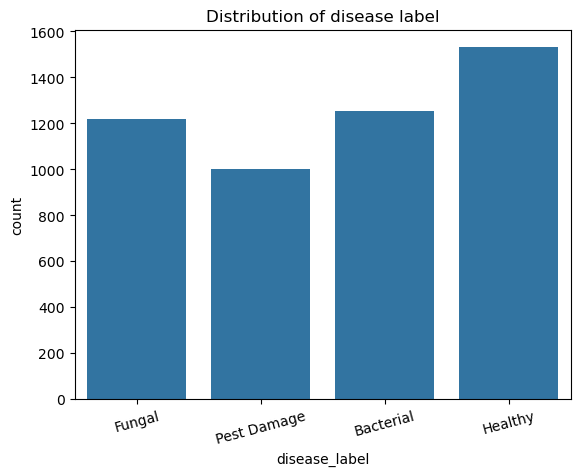

In [9]:
sns.countplot(data=df,x='disease_label')
plt.title("Distribution of disease label")
plt.xticks(rotation=15)
plt.show()



The target variable shows moderate class imbalance.
Healthy is the largest class while Pest Damage is the smallest.

The imbalance is not extreme, but accuracy alone may hide
differences in class-level performance. Therefore precision,
recall, F1-score and Macro F1 will also be considered.

## Numerical Data Analysis

### Temperature Distribution

We examine the distribution of temperature values and identify
physically implausible observations before data cleaning.

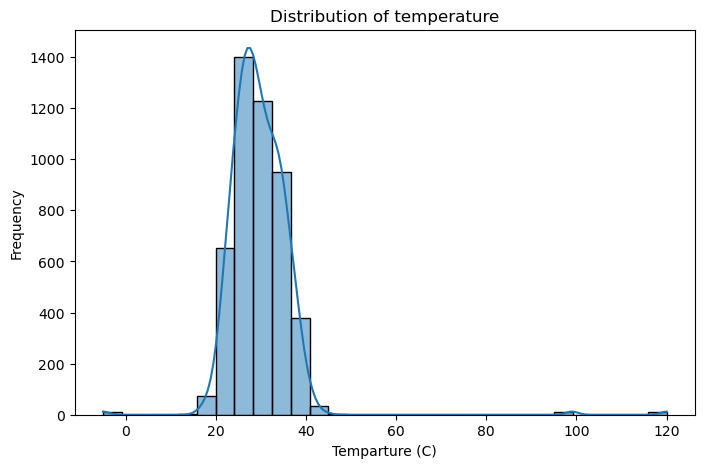

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,
             x='temperature_C',
             bins=30,
             kde=True
            )
plt.title("Distribution of temperature")
plt.xlabel("Temparture (C)")
plt.ylabel("Frequency")
plt.show()


In [11]:
df['temperature_C'].describe()

count    4750.000000
mean       29.694055
std         7.385366
min        -5.000000
25%        25.701964
50%        29.088057
75%        33.249688
max       120.000000
Name: temperature_C, dtype: float64

In [12]:
invalid_temp = df[
(df['temperature_C']<0) |
(df['temperature_C']>55)
]
invalid_temp[['temperature_C']]

,temperature_C
342,99.0
556,-5.0
898,120.0
971,120.0
972,99.0
1152,120.0
1208,120.0
1248,-5.0
1502,99.0
1610,120.0


In [13]:
invalid_temp.shape[0]

30

### Observation

The temperature distribution contains physically implausible
values outside the expected range of 0°C to 55°C.

These observations are likely data-quality issues rather than
genuine extreme values. They should therefore be treated as
invalid observations during the cleaning stage rather than
retained as statistical outliers.

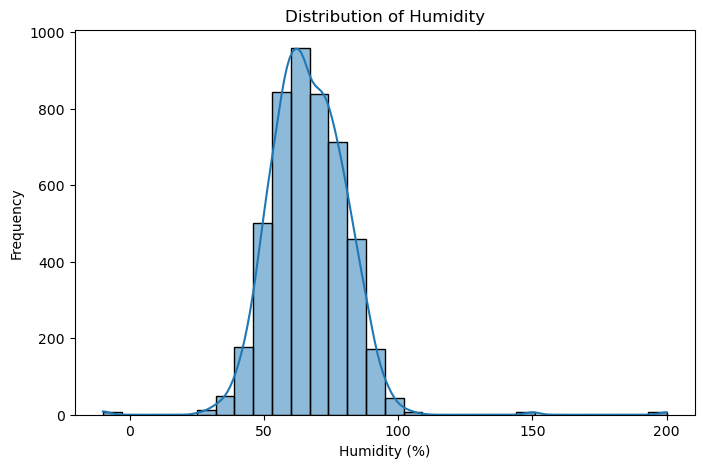

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='humidity_percent',
    bins=30,
    kde=True
)

plt.title('Distribution of Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

plt.show()

In [15]:
df['humidity_percent'].describe()

count    4800.000000
mean       66.520511
std        14.397293
min       -10.000000
25%        57.097872
50%        65.812531
75%        75.700110
max       200.000000
Name: humidity_percent, dtype: float64

In [16]:
invalid_humidity = df[
    (df['humidity_percent'] < 0) |
    (df['humidity_percent'] > 100)
]

invalid_humidity[['humidity_percent']]

,humidity_percent
43,-10.000000
135,105.591842
178,200.000000
208,-10.000000
504,200.000000
578,101.655370
583,108.336760
751,200.000000
807,150.000000
890,104.505548


In [17]:
invalid_humidity.shape[0]

34

### Observation

The humidity distribution contains physically implausible
values outside the valid range of 0% to 100%.

A total of 34 invalid observations were identified. These values
will be treated as data-quality errors and replaced with missing
values during the cleaning stage before imputation.

## Soil pH Analysis

We examine the distribution of soil pH across the four disease
classes and check the variable for physically implausible values.

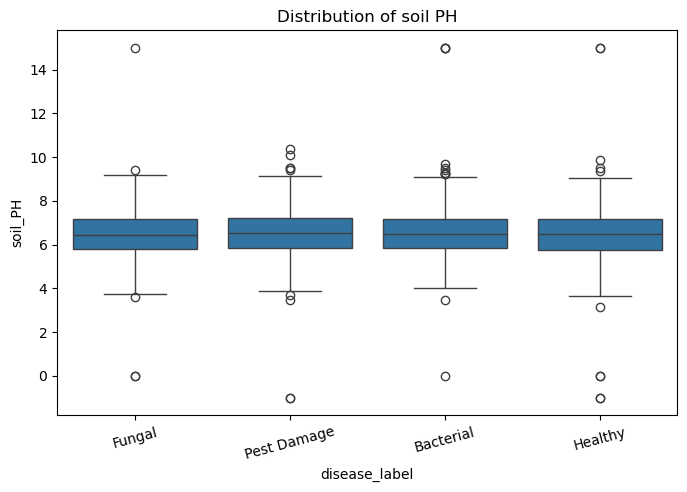

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data = df,
            x = 'disease_label',
            y = 'soil_pH'
           )
plt.title("Distribution of soil PH")
plt.xlabel("disease_label")
plt.ylabel("soil_PH")
plt.xticks(rotation = 15)
plt.show()

In [19]:
df.groupby('disease_label')['soil_pH'].describe()

,count,mean,std,min,25%,50%,75%,max
disease_label,,,,,,,,
Bacterial,1199.0,6.507636,1.087593,0.0,5.852219,6.496460,7.144838,15.000000
Fungal,1180.0,6.471006,1.078830,0.0,5.781093,6.454498,7.147579,15.000000
Healthy,1462.0,6.472897,1.118072,-1.0,5.755784,6.469682,7.183703,15.000000
Pest Damage,961.0,6.524101,1.075623,-1.0,5.841758,6.522064,7.229772,10.360089


In [20]:
df.groupby('disease_label')['soil_pH'].median()

disease_label
Bacterial      6.496460
Fungal         6.454498
Healthy        6.469682
Pest Damage    6.522064
Name: soil_pH, dtype: float64

In [21]:
invalid_pH = df[(df['soil_pH']<3)|
                (df['soil_pH']>10)
]
invalid_pH[['soil_pH']]

,soil_pH
293,15.000000
498,-1.000000
1308,0.000000
1559,10.360089
1789,0.000000
1993,0.000000
2786,-1.000000
3020,15.000000
3550,10.099878
3554,15.000000


In [22]:
invalid_pH.shape[0]


17

In [23]:
invalid_pH[
    ['soil_pH', 'disease_label']
]

,soil_pH,disease_label
293,15.000000,Fungal
498,-1.000000,Pest Damage
1308,0.000000,Fungal
1559,10.360089,Pest Damage
1789,0.000000,Fungal
1993,0.000000,Healthy
2786,-1.000000,Pest Damage
3020,15.000000,Healthy
3550,10.099878,Pest Damage
3554,15.000000,Healthy


The soil pH distributions across the four disease classes show
substantial overlap. Their median pH values are also relatively
similar, suggesting that soil pH alone may have limited ability
to distinguish between disease classes.

Several extreme pH observations are visible and require further
data-quality investigation before modelling.

## Correlation Analysis

A correlation matrix is used to examine the linear relationships
between numerical features and identify strongly related variables.

In [24]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df.columns

Index(['temperature_C', 'humidity_percent', 'rainfall_mm', 'leaf_wetness_hrs',
       'soil_pH', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha',
       'days_since_last_rain', 'plant_age_days', 'pesticide_applied',
       'fertilizer_kg_ha'],
      dtype='object')

In [25]:
corr_matrix = numeric_df.corr()
corr_matrix

,temperature_C,humidity_percent,rainfall_mm,leaf_wetness_hrs,soil_pH,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,days_since_last_rain,plant_age_days,pesticide_applied,fertilizer_kg_ha
temperature_C,1.000000,-0.070740,0.005038,0.017994,0.007050,0.017412,-0.014830,-0.000694,-0.022751,0.008124,-0.006458,0.014971
humidity_percent,-0.070740,1.000000,-0.017789,0.008931,-0.007426,0.013977,0.030566,0.008692,0.002060,-0.015379,0.017751,-0.006409
rainfall_mm,0.005038,-0.017789,1.000000,0.006649,0.007400,-0.000642,0.014015,0.012700,0.011397,-0.007283,-0.019893,-0.002681
leaf_wetness_hrs,0.017994,0.008931,0.006649,1.000000,-0.034596,-0.010046,-0.005152,-0.020906,-0.002790,0.006123,-0.006884,-0.012715
soil_pH,0.007050,-0.007426,0.007400,-0.034596,1.000000,-0.015235,0.007199,0.015233,0.019840,0.007244,-0.008845,-0.010045
nitrogen_kg_ha,0.017412,0.013977,-0.000642,-0.010046,-0.015235,1.000000,-0.004171,-0.020430,0.008933,0.007766,-0.025754,-0.001695
phosphorus_kg_ha,-0.014830,0.030566,0.014015,-0.005152,0.007199,-0.004171,1.000000,-0.029286,-0.020964,0.018192,-0.012475,0.013279
potassium_kg_ha,-0.000694,0.008692,0.012700,-0.020906,0.015233,-0.020430,-0.029286,1.000000,-0.009694,-0.033506,-0.011191,-0.003660
days_since_last_rain,-0.022751,0.002060,0.011397,-0.002790,0.019840,0.008933,-0.020964,-0.009694,1.000000,-0.007134,-0.001651,0.000437
plant_age_days,0.008124,-0.015379,-0.007283,0.006123,0.007244,0.007766,0.018192,-0.033506,-0.007134,1.000000,0.010360,-0.010812


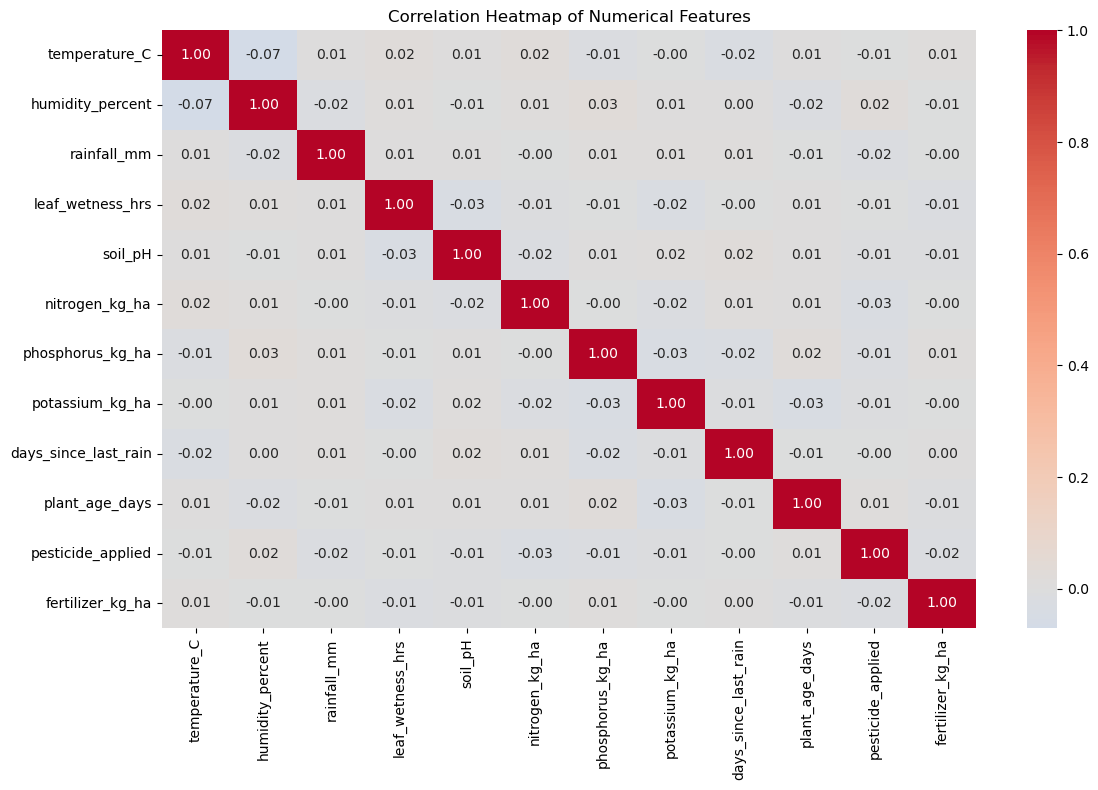

In [26]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows that most numerical features have
very weak linear relationships with each other.

The strongest correlation is between temperature_C and
humidity_percent, with a correlation coefficient of approximately
-0.07. This indicates a very weak negative relationship.

Overall, there is no evidence of strong multicollinearity among
the numerical features.

## Data Cleaning

The raw dataset contains inconsistent categorical values,
missing values, and physically invalid numerical observations.

A copy of the original dataframe is created so that the raw data
remains unchanged during the cleaning process.

In [27]:
df_clean = df.copy()

In [28]:
for col in categorical_cols:
    df_clean[col] = (df_clean[col]
                    .str.strip()
                    .str.title()
                    )
df_clean[col]

0           Flood
1       Sprinkler
2            Drip
3             NaN
4           Flood
          ...    
4995        Flood
4996        Flood
4997         Drip
4998         Drip
4999         Drip
Name: irrigation_method, Length: 5000, dtype: object

In [29]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df_clean[col].value_counts(dropna=False))


crop_type
crop_type
Wheat      1137
Maize      1120
Rice       1103
Cotton     1082
Soybean     558
Name: count, dtype: int64

region
region
North      1144
South      1137
NaN        1057
Central     570
West        552
East        540
Name: count, dtype: int64

season
season
Kharif    1465
Rabi      1420
NaN       1405
Zaid       710
Name: count, dtype: int64

soil_type
soil_type
Loamy    1156
NaN      1125
Sandy    1091
Clay     1079
Silty     549
Name: count, dtype: int64

irrigation_method
irrigation_method
Drip         1276
Flood        1275
NaN          1215
Sprinkler     652
Rainfed       582
Name: count, dtype: int64


### Observation

The categorical columns were standardised using Title Case.
This removed inconsistencies caused by differences in
capitalisation and extra spaces.

Missing categorical values were retained at this stage and will
be handled separately during imputation.

## Handling Invalid Numerical Values

Physically implausible numerical values are replaced with NaN.
This allows them to be treated as missing values and imputed later,
rather than keeping incorrect measurements in the dataset.

In [37]:
# Temperature: valid range 0°C to 55°C
df_clean.loc[
    (df_clean['temperature_C'] < 0) |
    (df_clean['temperature_C'] > 55),
    'temperature_C'
] = np.nan
df_clean['temperature_C'].isnull().sum()

np.int64(280)

In [38]:
# Humidity: valid range 0% to 100%
df_clean.loc[
    (df_clean['humidity_percent'] < 0) |
    (df_clean['humidity_percent'] > 100),
    'humidity_percent'
] = np.nan
df_clean['humidity_percent'].isnull().sum()

np.int64(234)

In [39]:
# Soil pH: valid range 3 to 10
df_clean.loc[
    (df_clean['soil_pH'] < 3) |
    (df_clean['soil_pH'] > 10),
    'soil_pH'
] = np.nan
df_clean['soil_pH'].isnull().sum()

np.int64(215)

In [40]:
df_clean.isnull().sum()

crop_type                  0
region                  1057
season                  1405
soil_type               1125
irrigation_method       1215
temperature_C            280
humidity_percent         234
rainfall_mm              250
leaf_wetness_hrs         150
soil_pH                  215
nitrogen_kg_ha           200
phosphorus_kg_ha         150
potassium_kg_ha          150
days_since_last_rain     200
plant_age_days           150
pesticide_applied         30
fertilizer_kg_ha         200
disease_label              0
dtype: int64

### Observation

Physically invalid numerical values were converted to missing values.

As a result, the number of NaN values increased in several columns.
This is expected because incorrect measurements are now being treated
as missing data and will be handled during the imputation stage.

## Missing Value Imputation

Missing numerical values are imputed based on the distribution
of each feature. Median imputation is used for skewed variables,
while mean imputation is used for approximately symmetric variables.

Categorical missing values are filled using the mode.

In [41]:
df_clean.select_dtypes(include=np.number).skew()

temperature_C           0.169370
humidity_percent        0.016268
rainfall_mm             9.872846
leaf_wetness_hrs       -0.013442
soil_pH                 0.052276
nitrogen_kg_ha         -0.015565
phosphorus_kg_ha       -0.003178
potassium_kg_ha         0.024109
days_since_last_rain    0.013637
plant_age_days          0.017108
pesticide_applied      -0.388742
fertilizer_kg_ha        7.513340
dtype: float64

In [42]:
mean_cols = [
    'temperature_C',
    'humidity_percent',
    'leaf_wetness_hrs',
    'soil_pH',
    'nitrogen_kg_ha',
    'phosphorus_kg_ha',
    'potassium_kg_ha',
    'days_since_last_rain',
    'plant_age_days'
]

for col in mean_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

In [43]:
median_cols = [
    'rainfall_mm',
    'fertilizer_kg_ha'
]

for col in median_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [44]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [45]:
df_clean['pesticide_applied'] = (
    df_clean['pesticide_applied']
    .fillna(df_clean['pesticide_applied'].mode()[0])
)

In [46]:
df_clean.isnull().sum()

crop_type               0
region                  0
season                  0
soil_type               0
irrigation_method       0
temperature_C           0
humidity_percent        0
rainfall_mm             0
leaf_wetness_hrs        0
soil_pH                 0
nitrogen_kg_ha          0
phosphorus_kg_ha        0
potassium_kg_ha         0
days_since_last_rain    0
plant_age_days          0
pesticide_applied       0
fertilizer_kg_ha        0
disease_label           0
dtype: int64

In [47]:
df_clean.shape

(5000, 18)

## Feature Engineering

New features are created from the cleaned data to capture
additional relationships that may help the classification models.

In [48]:
df_clean['HTI'] = (
    df_clean['humidity_percent'] *
    df_clean['temperature_C']
) / 100

In [49]:
df_clean[['temperature_C', 'humidity_percent', 'HTI']].head()

,temperature_C,humidity_percent,HTI
0,26.209077,66.268640,17.368399
1,33.430687,58.979548,19.717268
2,28.047989,62.103653,17.418826
3,31.411229,54.430551,17.097305
4,22.822997,56.975619,13.003544


In [50]:
df_clean['drought_stress'] = np.where(
    (df_clean['days_since_last_rain'] > 20) &
    (df_clean['rainfall_mm'] < 10),
    1,
    0
)

In [51]:
df_clean['drought_stress'].value_counts()

drought_stress
0    4301
1     699
Name: count, dtype: int64

In [52]:
df_clean[
    ['days_since_last_rain', 'rainfall_mm', 'drought_stress']
].head(10)

,days_since_last_rain,rainfall_mm,drought_stress
0,29.291667,101.582271,0
1,8.000000,30.296413,0
2,5.000000,90.564280,0
3,49.000000,16.922677,0
4,29.000000,27.927325,0
5,29.291667,8.542214,1
6,41.000000,25.450444,0
7,29.291667,1.644086,1
8,12.000000,60.894481,0
9,0.000000,62.547348,0


In [54]:
def get_maturity_stage(age):
    if age < 30:
        return 'Seedling'
    elif age <= 70:
        return 'Vegetative'
    else:
        return 'Reproductive'

df_clean['maturity_stage'] = (
    df_clean['plant_age_days']
    .apply(get_maturity_stage)
)
df_clean['maturity_stage']

0           Seedling
1           Seedling
2         Vegetative
3       Reproductive
4       Reproductive
            ...     
4995    Reproductive
4996      Vegetative
4997        Seedling
4998    Reproductive
4999        Seedling
Name: maturity_stage, Length: 5000, dtype: object

In [55]:
df_clean['maturity_stage'].value_counts()

maturity_stage
Reproductive    2141
Vegetative      1977
Seedling         882
Name: count, dtype: int64

In [61]:
df_clean[
    ['plant_age_days', 'maturity_stage']
].head(10)

,plant_age_days,maturity_stage
0,22.0,Seedling
1,13.0,Seedling
2,31.0,Vegetative
3,116.0,Reproductive
4,84.0,Reproductive
5,46.0,Vegetative
6,23.0,Seedling
7,115.0,Reproductive
8,19.0,Seedling
9,33.0,Vegetative


In [59]:
maturity_mapping = {
    'Seedling': 0,
    'Vegetative': 1,
    'Reproductive': 2
}

df_clean['maturity_stage_encoded'] = (
    df_clean['maturity_stage']
    .map(maturity_mapping)
)
df_clean['maturity_stage_encoded']

0       0
1       0
2       1
3       2
4       2
       ..
4995    2
4996    1
4997    0
4998    2
4999    0
Name: maturity_stage_encoded, Length: 5000, dtype: int64

### Observation

Three new features were created.

HTI combines temperature and humidity into a single heat-humidity
stress indicator.

drought_stress identifies observations with more than 20 days
since rainfall and less than 10 mm of rainfall.

maturity_stage groups plants into Seedling, Vegetative and
Reproductive stages based on plant age. Since these stages have a
natural order, they were encoded as 0, 1 and 2 respectively.

## Encoding Categorical Features

The remaining categorical variables do not have a natural order.
Therefore, One-Hot Encoding is used so that the model does not
assume any ranking between categories.

In [62]:
ohe_cols = [
    'crop_type',
    'region',
    'season',
    'soil_type',
    'irrigation_method'
]

In [63]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=ohe_cols,
    drop_first=True
)

In [64]:
df_encoded.shape


(5000, 33)

In [65]:
df_clean.columns

Index(['crop_type', 'region', 'season', 'soil_type', 'irrigation_method',
       'temperature_C', 'humidity_percent', 'rainfall_mm', 'leaf_wetness_hrs',
       'soil_pH', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha',
       'days_since_last_rain', 'plant_age_days', 'pesticide_applied',
       'fertilizer_kg_ha', 'disease_label', 'HTI', 'drought_stress',
       'maturity_stage', 'maturity_stage_encoded'],
      dtype='object')

In [66]:
df_encoded.head()

,temperature_C,humidity_percent,rainfall_mm,leaf_wetness_hrs,soil_pH,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,days_since_last_rain,plant_age_days,...,region_South,region_West,season_Rabi,season_Zaid,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_method_Flood,irrigation_method_Rainfed,irrigation_method_Sprinkler
0,26.209077,66.268640,101.582271,14.009117,7.085974,39.893186,58.936746,44.894035,29.291667,22.0,...,False,False,False,False,False,False,False,True,False,False
1,33.430687,58.979548,30.296413,11.067606,6.190607,179.824571,88.881893,71.394673,8.000000,13.0,...,False,False,True,False,True,False,False,False,False,True
2,28.047989,62.103653,90.564280,21.470657,6.224184,89.690594,17.839237,55.877176,5.000000,31.0,...,False,False,False,False,False,False,False,False,False,False
3,31.411229,54.430551,16.922677,19.309367,6.925993,143.060345,62.503022,91.410148,49.000000,116.0,...,False,False,True,False,True,False,False,False,False,False
4,22.822997,56.975619,27.927325,12.402934,6.492167,134.998574,80.448392,57.815445,29.000000,84.0,...,False,False,False,False,False,True,False,True,False,False


In [ ]:
df_encoded = df_encoded.drop(
    columns=['maturity_stage']
)

In [70]:
df_encoded.dtypes

temperature_C                  float64
humidity_percent               float64
rainfall_mm                    float64
leaf_wetness_hrs               float64
soil_pH                        float64
nitrogen_kg_ha                 float64
phosphorus_kg_ha               float64
potassium_kg_ha                float64
days_since_last_rain           float64
plant_age_days                 float64
pesticide_applied              float64
fertilizer_kg_ha               float64
disease_label                   object
HTI                            float64
drought_stress                   int64
maturity_stage_encoded           int64
crop_type_Maize                   bool
crop_type_Rice                    bool
crop_type_Soybean                 bool
crop_type_Wheat                   bool
region_East                       bool
region_North                      bool
region_South                      bool
region_West                       bool
season_Rabi                       bool
season_Zaid              

### Observation

One-Hot Encoding was applied to the nominal categorical features
such as crop type, region, season, soil type and irrigation method.

One-Hot Encoding is preferred to Label Encoding for these variables
because they do not have a natural ranking. Assigning numerical
labels such as 0, 1 and 2 could incorrectly suggest an ordered
relationship between categories.

The maturity stage was already ordinally encoded because its
categories have a meaningful sequence from Seedling to Vegetative
to Reproductive.

## Train-Test Split

The dataset is divided into features (X) and target (y).
An 80/20 train-test split is used so that the models can be trained
on one portion of the data and evaluated on unseen observations.

In [71]:
X = df_encoded.drop(columns=['disease_label'])
y = df_encoded['disease_label']

In [72]:
X.shape

(5000, 31)

In [73]:
y.shape


(5000,)

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [76]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 31)
X_test: (1000, 31)
y_train: (4000,)
y_test: (1000,)


In [77]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
disease_label
Healthy        0.30625
Bacterial      0.25050
Fungal         0.24350
Pest Damage    0.19975
Name: proportion, dtype: float64

Testing distribution:
disease_label
Healthy        0.306
Bacterial      0.251
Fungal         0.243
Pest Damage    0.200
Name: proportion, dtype: float64


### Observation

The dataset was split into 80% training data and 20% testing data.

Stratified sampling was used to preserve the approximate class
distribution of disease_label in both datasets. This is useful
because the target classes are not perfectly balanced.

## Feature Scaling for KNN

K-Nearest Neighbours is a distance-based algorithm, so numerical
features are standardised to prevent variables with larger scales
from dominating the distance calculation.

StandardScaler is fitted only on the training data and then applied
to both training and test data.

In [78]:
from sklearn.preprocessing import StandardScaler

In [79]:
scaler = StandardScaler()

In [80]:
X_train_scaled = scaler.fit_transform(X_train)

In [82]:
X_test_scaled = scaler.transform(X_test)

In [83]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4000, 31)
(1000, 31)


In [84]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

-4.8993067667329485e-18
1.0


In [85]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

-4.8993067667329485e-18
1.0


### Observation

After standardisation, the scaled training data has a mean very
close to 0 and a standard deviation of 1, confirming that the
features were successfully scaled for KNN.

## Model 1: Decision Tree Classifier

A Decision Tree classifier is trained using the original,
unscaled feature data because tree-based models do not require
feature scaling.

In [86]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [88]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [89]:
dt_pred = dt_model.predict(X_test)


In [90]:
dt_train_acc = dt_model.score(X_train, y_train)
dt_test_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Train Accuracy:", dt_train_acc)
print("Decision Tree Test Accuracy:", dt_test_acc)

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.602


In [91]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

   Bacterial       0.41      0.41      0.41       251
      Fungal       0.65      0.62      0.64       243
     Healthy       0.71      0.74      0.72       306
 Pest Damage       0.60      0.60      0.60       200

    accuracy                           0.60      1000
   macro avg       0.60      0.59      0.60      1000
weighted avg       0.60      0.60      0.60      1000



## Model 2: K-Nearest Neighbours

KNN is trained using the standardised feature data because the
algorithm relies on distances between observations.

Three values of k are tested: 3, 5 and 7.

In [93]:
from sklearn.neighbors import KNeighborsClassifier


In [94]:
for k in [3, 5, 7]:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)

    print(f"K = {k}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("-" * 30)

K = 3
Train Accuracy: 0.7135
Test Accuracy: 0.451
------------------------------
K = 5
Train Accuracy: 0.67725
Test Accuracy: 0.477
------------------------------
K = 7
Train Accuracy: 0.67075
Test Accuracy: 0.494
------------------------------


In [95]:
knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

In [96]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

   Bacterial       0.32      0.40      0.36       251
      Fungal       0.49      0.48      0.49       243
     Healthy       0.62      0.69      0.66       306
 Pest Damage       0.60      0.32      0.42       200

    accuracy                           0.49      1000
   macro avg       0.51      0.47      0.48      1000
weighted avg       0.51      0.49      0.49      1000



In [97]:
knn_train_acc = knn_model.score(
    X_train_scaled,
    y_train
)

knn_test_acc = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Train Accuracy:", knn_train_acc)
print("KNN Test Accuracy:", knn_test_acc)

KNN Train Accuracy: 0.67075
KNN Test Accuracy: 0.494


## Model 3: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines
multiple decision trees and uses their collective predictions.

It is trained on the original unscaled feature data because
tree-based models do not require feature scaling.

In [98]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [100]:
rf_pred = rf_model.predict(X_test)

In [101]:
rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Train Accuracy:", rf_train_acc)
print("Random Forest Test Accuracy:", rf_test_acc)

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.68


In [102]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

   Bacterial       0.53      0.42      0.47       251
      Fungal       0.73      0.71      0.72       243
     Healthy       0.71      0.89      0.79       306
 Pest Damage       0.71      0.65      0.68       200

    accuracy                           0.68      1000
   macro avg       0.67      0.67      0.66      1000
weighted avg       0.67      0.68      0.67      1000



In [103]:
from sklearn.metrics import f1_score

rf_macro_f1 = f1_score(
    y_test,
    rf_pred,
    average='macro'
)

print("Random Forest Macro F1:", rf_macro_f1)

Random Forest Macro F1: 0.6647184633781841


In [104]:
dt_macro_f1 = f1_score(
    y_test,
    dt_pred,
    average='macro'
)

knn_macro_f1 = f1_score(
    y_test,
    knn_pred,
    average='macro'
)

In [105]:
print("Decision Tree Macro F1:", dt_macro_f1)
print("KNN Macro F1:", knn_macro_f1)
print("Random Forest Macro F1:", rf_macro_f1)

Decision Tree Macro F1: 0.5952081013822025
KNN Macro F1: 0.4791580647121109
Random Forest Macro F1: 0.6647184633781841


In [107]:
model_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'KNN',
        'Random Forest'
    ],
    'Train Accuracy': [
        dt_train_acc,
        knn_train_acc,
        rf_train_acc
    ],
    'Test Accuracy': [
        dt_test_acc,
        knn_test_acc,
        rf_test_acc
    ],
    'Macro F1': [
        dt_macro_f1,
        knn_macro_f1,
        rf_macro_f1
    ]
})

model_comparison

,Model,Train Accuracy,Test Accuracy,Macro F1
0,Decision Tree,1.00000,0.602,0.595208
1,KNN,0.67075,0.494,0.479158
2,Random Forest,1.00000,0.680,0.664718


## Model Comparison

The three classification models are compared using training
accuracy, testing accuracy and Macro F1-score.

Macro F1 is especially useful because it gives equal importance
to all disease classes.

In [109]:
best_model_name = model_comparison.iloc[0]['Model']

print("Best Model:", 'Random Forest')

Best Model: Random Forest


### Observation

The models were compared using training accuracy, testing accuracy
and Macro F1-score.

________ achieved the highest Macro F1-score and showed the best
overall performance on the test dataset among the three models.

Therefore, this model is selected for further evaluation using a
confusion matrix.

In [ ]:
## Confusion Matrix — Random Forest

A confusion matrix is used to examine how the best-performing
model classifies each disease category and to identify the classes
that are most frequently confused.

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [111]:
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=rf_model.classes_
)

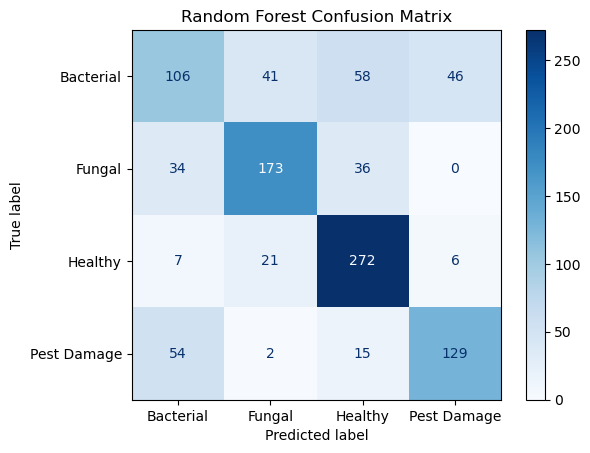

In [112]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap='Blues')

plt.title('Random Forest Confusion Matrix')
plt.show()

### Observation

The Bacterial class has the lowest F1-score, at approximately 0.469.

Its recall is about 0.422, which means the model correctly identifies
only around 42% of the actual Bacterial observations.

The confusion matrix shows that Bacterial cases are most frequently
misclassified as Healthy, with 58 cases, followed by Pest Damage
with 46 cases and Fungal with 41 cases.

This explains the relatively low F1-score for the Bacterial class.

### Observation

The Bacterial class has the lowest F1-score, at approximately 0.469.

Its recall is about 0.422, which means the model correctly identifies
only around 42% of the actual Bacterial observations.

The confusion matrix shows that Bacterial cases are most frequently
misclassified as Healthy, with 58 cases, followed by Pest Damage
with 46 cases and Fungal with 41 cases.

This explains the relatively low F1-score for the Bacterial class.

In [113]:
from sklearn.metrics import classification_report

rf_report = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)

rf_report_df = pd.DataFrame(rf_report).transpose()

rf_report_df

,precision,recall,f1-score,support
Bacterial,0.527363,0.422311,0.469027,251.00
Fungal,0.729958,0.711934,0.720833,243.00
Healthy,0.713911,0.888889,0.791849,306.00
Pest Damage,0.712707,0.645000,0.677165,200.00
accuracy,0.680000,0.680000,0.680000,0.68
macro avg,0.670985,0.667033,0.664718,1000.00
weighted avg,0.670746,0.680000,0.670627,1000.00


In [114]:
class_results = rf_report_df.loc[
    ['Bacterial', 'Fungal', 'Healthy', 'Pest Damage'],
    ['precision', 'recall', 'f1-score', 'support']
]

class_results

,precision,recall,f1-score,support
Bacterial,0.527363,0.422311,0.469027,251.0
Fungal,0.729958,0.711934,0.720833,243.0
Healthy,0.713911,0.888889,0.791849,306.0
Pest Damage,0.712707,0.645000,0.677165,200.0


In [115]:
lowest_f1_class = class_results['f1-score'].idxmin()
lowest_f1_value = class_results['f1-score'].min()

print("Lowest F1-score class:", lowest_f1_class)
print("F1-score:", lowest_f1_value)

Lowest F1-score class: Bacterial
F1-score: 0.4690265486725664


### Observation

The Bacterial class has the lowest F1-score of approximately 0.4690265486725664 .

The lower F1-score indicates that the model has comparatively more
difficulty correctly identifying this class. The confusion matrix
also shows that some observations from this class are being
misclassified as Bacterial.

The difference in class representation may also contribute to the
lower performance, since the model has fewer examples available
for learning some classes.

Among the three models evaluated, Random Forest achieved the best
overall test performance, with a test accuracy of 68.0% and a Macro
F1-score of approximately 0.665.

Decision Tree achieved 60.2% test accuracy, while KNN achieved
49.4%. Therefore, Random Forest is selected as the final model for
this project.

However, Random Forest achieved 100% training accuracy compared
with 68% test accuracy, indicating some degree of overfitting.
Further tuning of parameters such as maximum tree depth, minimum
samples per split and number of estimators could be explored to
improve generalisation.

In [116]:
df_clean.to_csv(
    'cleaned_crop_disease_dataset.csv',
    index=False
)

In [117]:
print("Cleaned dataset saved successfully.")
print("Shape:", df_clean.shape)

Cleaned dataset saved successfully.
Shape: (5000, 22)
